## This notebook assumes the 0-inital-checkpoint notebook completed first. 

This notebook relies on the checkpoint data. As checkpoint data covers news crawled from web, we are not able to share this publicly, thus initial notebook is shared to re-create the checkpoints. The resulting dataset might be slighly different due to changing online sources, thus may effect the final experiment results but this difference is expected to be neglicable as the outcome is aggregation of thousands of news. 

In [21]:
# pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
# pip install transformers sentence-transformers scikit-learn requests trafilatura nltk
# pip install lxml_html_clean

In [22]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\aratb\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [23]:
import os
import re
from typing import Iterable, List, Tuple, Optional, Dict

from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

from sentence_transformers import SentenceTransformer

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity


### read from the checkpoint and prepare feature set

In [24]:
# first we saved the checkpoint, now we reload it
# repeat the first process just once, and later use the saved file

# this file is not given in the repo due to copyright issues
# users can create their own by running the above code
# as the article retrival is subject to change over time, results may vary slightly
# however, as study relies on more than 37 thousand articles, small differences should not impact the overall findings
# we store the original checkpoint file for reference, researchers can request access by contacting the authors

df = pd.read_csv("gdelt_sentiment_with_text_checpoint.csv")

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37582 entries, 0 to 37581
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   raw_extras                   31472 non-null  object 
 1   clean_source                 37582 non-null  object 
 2   clean_image                  31424 non-null  object 
 3   clean_title                  16283 non-null  object 
 4   clean_link                   37582 non-null  object 
 5   Timestamp                    37582 non-null  object 
 6   clean_tone                   37582 non-null  float64
 7   positive_score               37582 non-null  float64
 8   negative_score               37582 non-null  float64
 9   polarity                     37582 non-null  float64
 10  activity_ref_density         37582 non-null  float64
 11  self_group_ref_density       37582 non-null  float64
 12  word_count                   37582 non-null  int64  
 13  num_mentions    

In [26]:
df[df['article_text'].notnull()]['article_text'].str.len().describe()

count     27196.000000
mean       3852.487388
std        3764.701087
min         103.000000
25%        2019.750000
50%        3079.000000
75%        4534.000000
max      221204.000000
Name: article_text, dtype: float64

In [27]:
df[df['article_text'].notnull()]['clean_link'].tail(10).values

array(['https://gulfnews.com/business/markets/saudi-arabias-pif-launches-new-property-developer-for-staff-housing-market-1.1729515752593',
       'https://www.khaleejtimes.com/business/dh128b-al-maktoum-international-airport-project-fuels-real-estate-boom-in-dubai-south',
       'https://www.thenationalnews.com/arts-culture/music-stage/2025/06/13/mamma-mia-musical-abu-dhabi-cast/',
       'https://www.khaleejtimes.com/uae/women-founders-boardroom-leaders-rise',
       'https://www.cnbc.com/2025/06/13/israel-iran-where-equity-investors-can-hide-amid-market-turmoil.html',
       'https://www.khaleejtimes.com/business/aviation/israel-attacks-iran-uae-flights-cancelleddelayed',
       'https://gulfbusiness.com/abu-dhabi-sovereign-wealth-fund-mubadalas-assets-jump-9-in-2024/',
       'https://www.forbes.com/councils/forbesbusinesscouncil/2025/05/08/investing-smartly-as-dubai-aims-for-global-financial-hub/',
       'https://www.arabianbusiness.com/industries/real-estate/abu-dhabi-property-pr

In [28]:
df[df['article_text'].notnull()]['article_text'].tail(10).values

array(['SARCC will meet the rising demand for housing solutions in both public and private sector\r\nDubai: Saudi Arabia’s Public Investment Fund (PIF) launches a new property development company aimed at providing housing for workers on major construction projects.\r\nThe smart accommodation for residential complexes company (SARCC) will meet the rising demand for housing solutions in both public and private sector initiatives as the country pursues its extensive infrastructure development plans.\r\nSARCC intends to revolutionise the staff housing sector by creating and managing complexes that adhere to international standards set by the international finance corporation and the european bank for reconstruction and development.\r\nPIF seeks to transform key sectors through significant investments in infrastructure, real estate, technology, and renewable energy, both domestically and globally.\r\nWith an emphasis on fostering innovation and strengthening the private sector, PIF has ini

In [29]:
econ_keywords = [
    "economy", "economic", "macroeconomic", "microeconomic", "finance", "financial", "financing", "fintech",
    "inflation", "deflation", "stagflation", "interest rate", "interest rates", "rate hike", "rate cut",
    "central bank", "federal reserve", "fed", "ecb", "bank of england", "monetary policy", "fiscal policy",
    "stock market", "equity", "equities", "shares", "bond", "bonds", "treasury", "yield", "credit", "debt",
    "sovereign debt", "budget", "surplus", "deficit", "gdp", "gross domestic product", "growth", "recession",
    "contraction", "expansion", "unemployment", "labor market", "labour market", "tax", "taxation", "tariff",
    "trade", "exports", "imports", "trade balance", "current account", "currency", "exchange rate", "forex",
    "commodities", "commodity", "oil price", "oil prices", "petroleum", "brent", "wti", "gasoline", "diesel",
    "natural gas", "metals", "gold", "silver", "copper", "aluminium", "crypto", "cryptocurrency", "bitcoin",
    "ethereum", "blockchain", "web3", "investment", "investing", "venture capital", "vc", "private equity", "pe",
    "ipo", "initial public offering", "listing", "merger", "acquisition", "m&a", "earnings", "profit", "loss",
    "margin", "revenue", "dividend", "share buyback", "share repurchase", "quarterly results", "guidance",
    "outlook", "rating", "downgrade", "upgrade"
]

real_keywords = [
    "real estate", "property", "properties", "housing", "home price", "home prices", "house price", "house prices",
    "mortgage", "mortgages", "mortgage rate", "mortgage rates", "refinance", "refinancing", "construction",
    "builder", "builders", "building", "developer", "development", "residential", "commercial real estate",
    "commercial property", "office space", "office market", "retail property", "industrial property", "warehouse",
    "logistics real estate", "land", "lease", "leasing", "rental", "rent", "rentals", "tenant", "tenancy",
    "vacancy", "vacancies", "occupancy rate", "housing market", "housing supply", "housing demand",
    "affordable housing", "home sales", "existing home sales", "new home sales", "pending home sales",
    "housing starts", "building permits", "housing inventory", "real estate market", "price index", "home value",
    "zoning", "foreclosure", "eviction", "distressed property", "real estate investment trust", "reit",
    "reit dividend", "valuation", "appraisal", "brokerage", "estate agent", "open house", "mortgage delinquency",
    "housing bubble", "rent control", "property tax", "strata", "condominium", "condo", "apartment",
    "multifamily", "single family", "luxury real estate", "prime property", "holiday home", "short term rental",
    "airbnb", "timeshare", "co-living", "co-working", "smart home", "green building", "energy efficient housing"
]

symbol_keywords = [
    "$", "€", "£", "¥", "₹", "₽", "₺", "%", "percent", "percentage", "per cent",
    "million", "billion", "trillion", "millions", "billions", "trillions",
    "bn", "mn", "usd", "eur", "gbp", "aed", "sar", "qar", "kwd", "omr", "bhd", "jpy", "cny"
]

all_keywords = econ_keywords + real_keywords + symbol_keywords
pattern = re.compile("(" + "|".join(re.escape(k) for k in all_keywords) + ")", re.IGNORECASE)

print(f"Initial dataset size: {len(df)} rows")

df = df.dropna(subset=["article_text"])
df = df[df["article_text"].astype(str).str.strip() != ""]
print(f"After removing missing/empty article_text: {len(df)} rows")

mask_keywords = df["article_text"].astype(str).str.contains(pattern)
df_filtered = df[mask_keywords].copy()
print(f"After keyword filtering: {len(df_filtered)} rows")

retained_pct = len(df_filtered) / len(df) * 100 if len(df) > 0 else 0
print(f"Retained {retained_pct:.2f}% of rows after filtering")

df = df_filtered


Initial dataset size: 37582 rows
After removing missing/empty article_text: 27196 rows


C:\Users\aratb\AppData\Local\Temp\ipykernel_5688\3954971147.py:48: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_keywords = df["article_text"].astype(str).str.contains(pattern)


After keyword filtering: 25585 rows
Retained 94.08% of rows after filtering


In [30]:
df.shape

(25585, 35)

### NSI Pipeline

In [31]:
if "Timestamp" not in df.columns or "article_text" not in df.columns:
    raise ValueError("df must contain 'Timestamp' and 'article_text'")

df_local = df.copy()
df_local["Timestamp"] = pd.to_datetime(df_local["Timestamp"], errors="coerce")
df_local = df_local.dropna(subset=["Timestamp"])
if df_local["Timestamp"].dt.tz is not None:
    df_local["Timestamp"] = df_local["Timestamp"].dt.tz_localize(None)

denom = (df_local["positive_score"] + df_local["negative_score"]).replace(0, np.nan)
df_local["nsi"] = (df_local["positive_score"] - df_local["negative_score"]) / denom

weekly_nsi = (
    df_local[["Timestamp", "nsi"]]
      .set_index("Timestamp")
      .resample("W-SUN")
      .median()
      .rolling(4, min_periods=1)
      .mean()
)
weekly_nsi.index.name = "date"

print("Rows after timestamp cleaning:", len(df_local))
print("Date range:", df_local["Timestamp"].min(), "→", df_local["Timestamp"].max())
print("Weekly NSI points:", len(weekly_nsi))


Rows after timestamp cleaning: 25585
Date range: 2015-04-01 03:15:00 → 2025-10-01 22:45:00
Weekly NSI points: 549


In [32]:
weekly_full = weekly_nsi.copy()
weekly_full["nsi_value"] = weekly_full["nsi"]
weekly_full["nsi_diff1"] = weekly_full["nsi"].diff()
weekly_full["nsi_vol4"] = weekly_full["nsi"].rolling(4, min_periods=1).std()
weekly_full["nsi_lag1"] = weekly_full["nsi"].shift(1)
weekly_full["nsi_lag4"] = weekly_full["nsi"].shift(4)
weekly_full["nsi_ma4"] = weekly_full["nsi"].rolling(4, min_periods=1).mean()
weekly_full["nsi_ema4"] = weekly_full["nsi"].ewm(span=4, min_periods=1).mean()

weekly_all = weekly_full

print("Weekly feature frame shape:", weekly_all.shape)
print("Weekly index range:", weekly_all.index.min(), "→", weekly_all.index.max())
print("Feature columns now:", [c for c in weekly_all.columns if c != "nsi"])


Weekly feature frame shape: (549, 8)
Weekly index range: 2015-04-05 00:00:00 → 2025-10-05 00:00:00
Feature columns now: ['nsi_value', 'nsi_diff1', 'nsi_vol4', 'nsi_lag1', 'nsi_lag4', 'nsi_ma4', 'nsi_ema4']


### Embedding Pipeline

In [33]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
texts = df_local["article_text"].fillna("").astype(str).tolist()

batch_size = 256
emb_chunks = []
for i in tqdm(range(0, len(texts), batch_size), desc="MiniLM embeddings"):
    emb = model.encode(
        texts[i:i+batch_size],
        batch_size=batch_size,
        normalize_embeddings=True,
        show_progress_bar=False
    )
    emb_chunks.append(emb)

emb_all = np.vstack(emb_chunks) if emb_chunks else np.empty((0, model.get_sentence_embedding_dimension()))
if emb_all.shape[0] != len(df_local):
    raise RuntimeError("Embedding count does not match cleaned article rows.")

emb_df = pd.DataFrame(emb_all, index=df_local["Timestamp"])
weekly_emb = emb_df.resample("W-SUN").mean()
weekly_emb.index.name = "date"
weekly_emb = weekly_emb.reindex(weekly_all.index)

print("Embeddings per article:", emb_all.shape)
print("Weekly embeddings shape:", weekly_emb.shape)
print("Weekly embeddings nan rows:", int(weekly_emb.isna().any(axis=1).sum()))


MiniLM embeddings: 100%|██████████| 100/100 [00:46<00:00,  2.15it/s]

Embeddings per article: (25585, 384)
Weekly embeddings shape: (549, 384)
Weekly embeddings nan rows: 2


In [34]:
train_start = pd.Timestamp("2015-09-01")
train_end = train_start + pd.DateOffset(years=5)

train_mask = (weekly_emb.index >= train_start) & (weekly_emb.index < train_end)
train_weeks = weekly_emb.loc[train_mask].dropna(how="any")
if train_weeks.shape[0] == 0:
    raise RuntimeError("No valid training weeks for PCA fit. Check date ranges.")

valid_weeks = weekly_emb.dropna(how="any")
if valid_weeks.shape[0] == 0:
    raise RuntimeError("No valid weeks for PCA after alignment. Check date ranges.")

n_components = 8
pca = PCA(n_components=n_components, random_state=0)
pca.fit(train_weeks.values)

Z_valid = pca.transform(valid_weeks.values)

pca_cols = [f"sem_pca{i}" for i in range(1, n_components + 1)]
weekly_pca = pd.DataFrame(index=weekly_emb.index, columns=pca_cols, dtype=float)
weekly_pca.loc[valid_weeks.index, pca_cols] = Z_valid

merged = weekly_all.join(weekly_pca, how="left")
for c in pca_cols:
    merged[f"{c}_smooth"] = merged[c].ewm(alpha=0.3, adjust=False).mean()
merged = merged.drop(columns=[c for c in pca_cols if c in merged.columns])

print("PCA components:", n_components)
print("PCA fit window:", train_start.date(), "to", (train_end - pd.Timedelta(days=1)).date())
print("PCA training weeks used:", int(train_weeks.shape[0]))
print("Explained variance ratio (first 3):", np.round(pca.explained_variance_ratio_[:3], 4).tolist())
print("Final feature columns added:", [f"{c}_smooth" for c in pca_cols])


PCA components: 8
PCA fit window: 2015-09-01 to 2020-08-31
PCA training weeks used: 261
Explained variance ratio (first 3): [0.13379999995231628, 0.09910000115633011, 0.05889999866485596]
Final feature columns added: ['sem_pca1_smooth', 'sem_pca2_smooth', 'sem_pca3_smooth', 'sem_pca4_smooth', 'sem_pca5_smooth', 'sem_pca6_smooth', 'sem_pca7_smooth', 'sem_pca8_smooth']


#### pca debug - curve plot

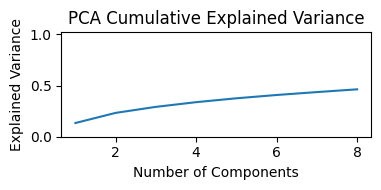

In [35]:
explained_var = pca.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

plt.figure(figsize=(4, 2))
plt.plot(
    np.arange(1, len(cum_explained_var) + 1),
    cum_explained_var
)
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()

### Save Dataset

In [36]:
out = (
    merged
      .drop(columns=[col for col in ["nsi"] if col in merged.columns])
      .reset_index()
      )


sent_path = "nsi_features_smooth.csv"
out.to_csv(sent_path, index=False)

print("Written file:", sent_path)
print("Output shape:", out.shape)
print("Output date range:", out['date'].min(), "→", out['date'].max())
print("Output columns:", out.columns.tolist())
print("Preview:")
display(out.head(3))


Written file: nsi_features_smooth.csv
Output shape: (549, 16)
Output date range: 2015-04-05 00:00:00 → 2025-10-05 00:00:00
Output columns: ['date', 'nsi_value', 'nsi_diff1', 'nsi_vol4', 'nsi_lag1', 'nsi_lag4', 'nsi_ma4', 'nsi_ema4', 'sem_pca1_smooth', 'sem_pca2_smooth', 'sem_pca3_smooth', 'sem_pca4_smooth', 'sem_pca5_smooth', 'sem_pca6_smooth', 'sem_pca7_smooth', 'sem_pca8_smooth']
Preview:


,date,nsi_value,nsi_diff1,nsi_vol4,nsi_lag1,nsi_lag4,nsi_ma4,nsi_ema4,sem_pca1_smooth,sem_pca2_smooth,sem_pca3_smooth,sem_pca4_smooth,sem_pca5_smooth,sem_pca6_smooth,sem_pca7_smooth,sem_pca8_smooth
0,2015-04-05,0.116883,NaN,NaN,NaN,NaN,0.116883,0.116883,-0.044141,0.045234,-0.043691,0.002065,-0.021973,-0.039735,0.038316,0.056725
1,2015-04-12,0.150108,0.033225,0.023494,0.116883,NaN,0.133496,0.137649,-0.040639,0.052303,-0.020528,0.001678,-0.033554,-0.028062,0.030258,0.062358
2,2015-04-19,0.237327,0.087219,0.062206,0.150108,NaN,0.168106,0.188505,-0.017064,0.040069,-0.014164,0.016889,-0.027740,-0.022490,0.030478,0.056834
